## Notebook to test .py implementation workflow

In [1]:
import numpy as np

from src.utils.seed import set_seed
from src.utils.plotting import plot_learning_curve
from src.utils.env import make_env
from src.utils.stats import compute_stats
from experiments.cartpole import run_experiments
from src.algorithms.dqn import DQNAgent


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/marzioformica/miniconda3/envs/rl-project/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/marzioformica/miniconda3/envs/rl-project/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/marzioformica/miniconda3/envs/rl-project/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/marzioformica/miniconda3/envs/rl-project/lib/python3.10/sit

In [2]:
# -----------------------
# Random baseline agent
# (placeholder for DQN/PPO/etc.)
# -----------------------
class RandomAgent:
    """
    A simple agent that takes random actions in the environment.
    This is a baseline for testing our environment and code setup.
    """
    def __init__(self, action_space):
        self.action_space = action_space

    def act(self, state):
        return self.action_space.sample()
    def set_eval_mode(self, mode: bool):
        pass

In [3]:
rnd_logs = run_experiments(
    agent_fn=lambda action_space, state_dim: RandomAgent(action_space),
    seeds=[0, 1, 2],
    n_episodes=100,
    eval_interval=10
)

dqn_logs = run_experiments(
    agent_fn=lambda action_space, state_dim: DQNAgent(
        action_space=action_space,
        state_dim=state_dim,
        gamma=0.99,
        batch_size=64,
        eps=1.0,
        eps_min=0.05,
        eps_decay=0.995,
        target_update_freq=100,
        buffer_capacity=10000,
        lr=1e-3
    ),
    seeds=[0, 1, 2],
    n_episodes=300,
    eval_interval=30
)

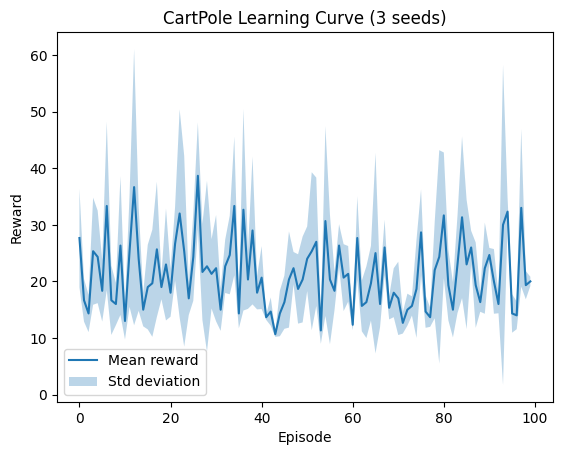

In [4]:
rewards_rnd = [logger.episode_rewards for logger in rnd_logs]
mean_rewards_rnd, std_rewards_rnd = compute_stats(rewards_rnd)
episodes = np.arange(len(mean_rewards_rnd))

plot_learning_curve(episodes, mean_rewards_rnd, std_rewards_rnd)

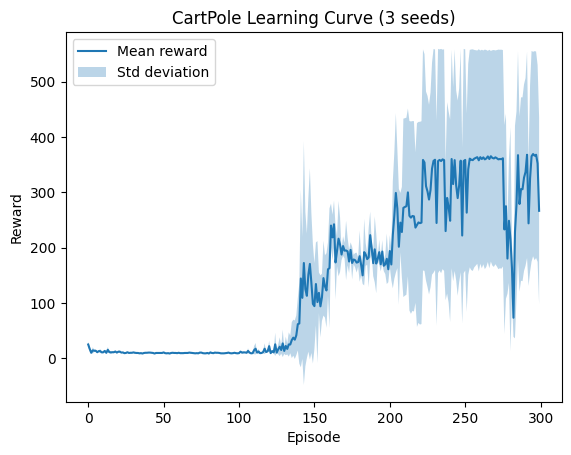

In [5]:
rewards_dqn = [logger.episode_rewards for logger in dqn_logs] 
mean_rewards_dqn, std_rewards_dqn = compute_stats(rewards_dqn)
episodes = np.arange(len(mean_rewards_dqn))

plot_learning_curve(episodes, mean_rewards_dqn, std_rewards_dqn)

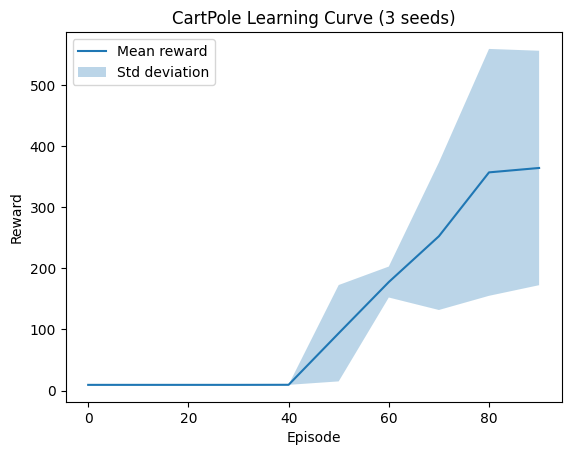

In [7]:
# plot evaluation rewards
eval_rewards_dqn = [logger.eval_rewards for logger in dqn_logs]
mean_eval_rewards_dqn, std_eval_rewards_dqn = compute_stats(eval_rewards_dqn)
eval_episodes = np.arange(len(mean_eval_rewards_dqn)) * 10
plot_learning_curve(eval_episodes, mean_eval_rewards_dqn, std_eval_rewards_dqn)

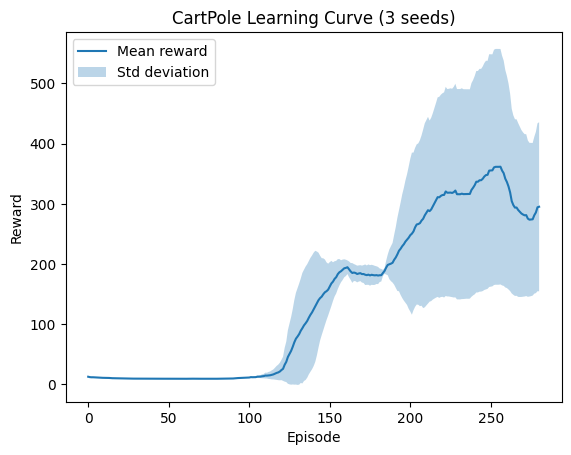

In [9]:
# plot episode reward (for dqn) with moving average

mva_ep_rewards_dqn = [logger.moving_average(window=20) for logger in dqn_logs]
mean_ep_rewards_dqn, std_ep_rewards_dqn = compute_stats(mva_ep_rewards_dqn)
episodes = np.arange(len(mean_ep_rewards_dqn))
plot_learning_curve(episodes, mean_ep_rewards_dqn, std_ep_rewards_dqn)

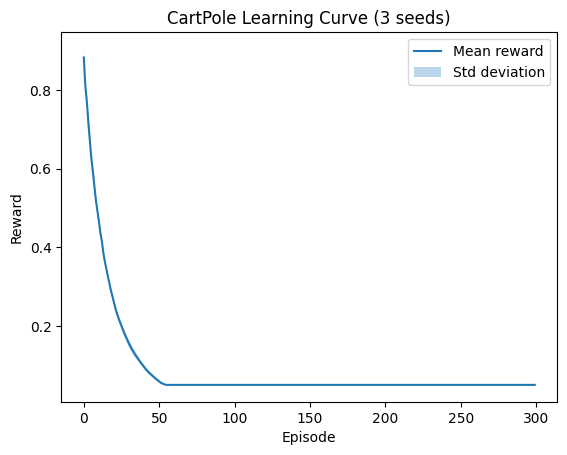

In [11]:
# plot epsilon decay for dqn
epsilons_dqn = [logger.epsilons for logger in dqn_logs]
mean_epsilons_dqn, std_epsilons_dqn = compute_stats(epsilons_dqn)
episodes = np.arange(len(mean_epsilons_dqn))
plot_learning_curve(episodes, mean_epsilons_dqn, std_epsilons_dqn)